<a href="https://colab.research.google.com/github/jaeheechillin3/pytorch_projects/blob/main/lenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

import torchvision.transforms as transforms
import torchvision.datasets as datasets

from sklearn import decomposition
from sklearn import manifold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from tqdm.notebook import tqdm, trange

import matplotlib.pyplot as plt
import numpy as np

import copy
import random
import time

In [2]:
# set seed for reproducability
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [3]:
# normalize data
train_data = datasets.MNIST(root='.data', train=True, download=True)

mean = train_data.data.float().mean() / 255
std = train_data.data.float().std() / 255

print(f'Calculated mean: {mean}')
print(f'Calculated std: {std}')

train_transforms = transforms.Compose([
                            transforms.RandomRotation(5, fill=(0,)),
                            transforms.RandomCrop(28, padding=2),
                            transforms.ToTensor(),
                            transforms.Normalize(mean=[mean], std=[std])
                                      ])

test_transforms = transforms.Compose([
                           transforms.ToTensor(),
                           transforms.Normalize(mean=[mean], std=[std])
                                     ])

train_data = datasets.MNIST(root='.data',
                            train=True,
                            download=True,
                            transform=train_transforms)

test_data = datasets.MNIST(root='.data',
                           train=False,
                           download=True,
                           transform=test_transforms)

VALID_RATIO = 0.9

n_train_examples = int(len(train_data) * VALID_RATIO)
n_valid_examples = len(train_data) - n_train_examples

train_data, valid_data = data.random_split(train_data,
                                           [n_train_examples, n_valid_examples])

valid_data = copy.deepcopy(valid_data)
valid_data.dataset.transform = test_transforms

print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_data)}')

BATCH_SIZE = 64

train_iterator = data.DataLoader(train_data,
                                 shuffle=True,
                                 batch_size=BATCH_SIZE)

valid_iterator = data.DataLoader(valid_data,
                                 batch_size=BATCH_SIZE)

test_iterator = data.DataLoader(test_data,
                                batch_size=BATCH_SIZE)


100%|██████████| 9.91M/9.91M [00:00<00:00, 29.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 929kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 6.96MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.82MB/s]


Calculated mean: 0.13066047430038452
Calculated std: 0.30810779333114624
Number of training examples: 54000
Number of validation examples: 6000
Number of testing examples: 10000


In [4]:
# trying out different filters/kernels
def plot_filter(images, filter):
    images = torch.cat([i.unsqueeze(0) for i in images], dim=0).cpu()
    filter = torch.FloatTensor(filter).unsqueeze(0).unsqueeze(0).cpu()

    n_images = images.shape[0]
    filtered_images = F.conv2d(images, filter)

    fig = plt.figure(figsize=(20, 5))

    for i in range(n_images):
        ax = fig.add_subplot(2, n_images, i + 1)
        ax.imshow(images[i].squeeze(0), cmap='bone')
        ax.set_title('Original')
        ax.axis('off')

        ax = fig.add_subplot(2, n_images, n_images + i + 1)
        ax.imshow(filtered_images[i].squeeze(0), cmap='bone')
        ax.set_title('Filtered')
        ax.axis('off')

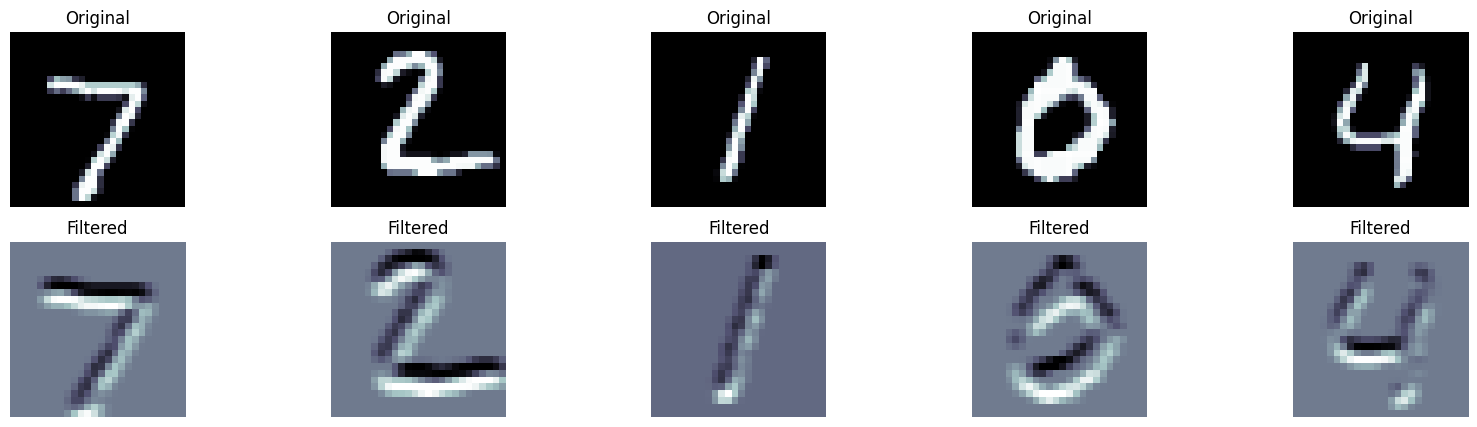

In [5]:
N_IMAGES = 5
images = [image for image, label in [test_data[i] for i in range(N_IMAGES)]]

# detecting horizontal edges
horizontal_filter = [[1, 2, 1],
                     [0, 0, 0],
                     [-1, -2, -1]]
plot_filter(images, horizontal_filter)

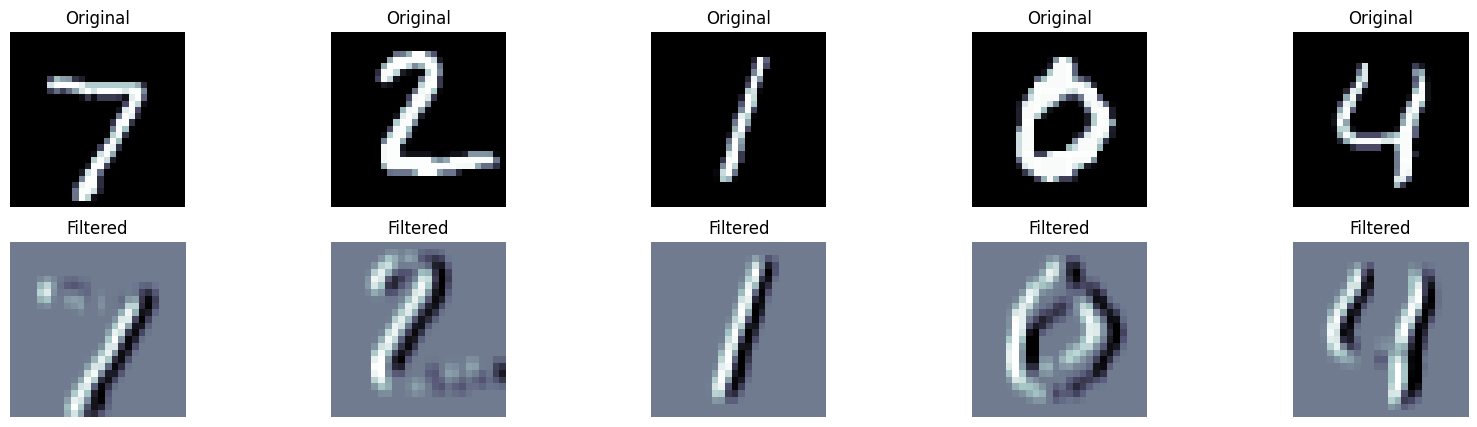

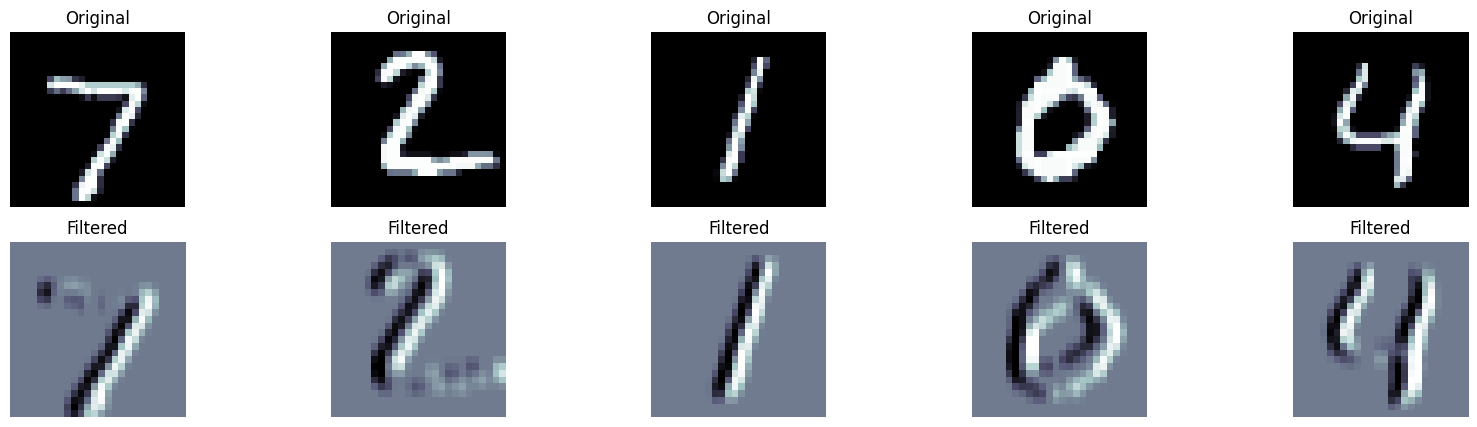

In [6]:
# detecting vertical edges
vertical_filter1 = [[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]]
plot_filter(images, vertical_filter1)

vertical_filter2 = [[1, 0, -1],
                   [2, 0, -2],
                   [1, 0, -1]]
plot_filter(images, vertical_filter2)

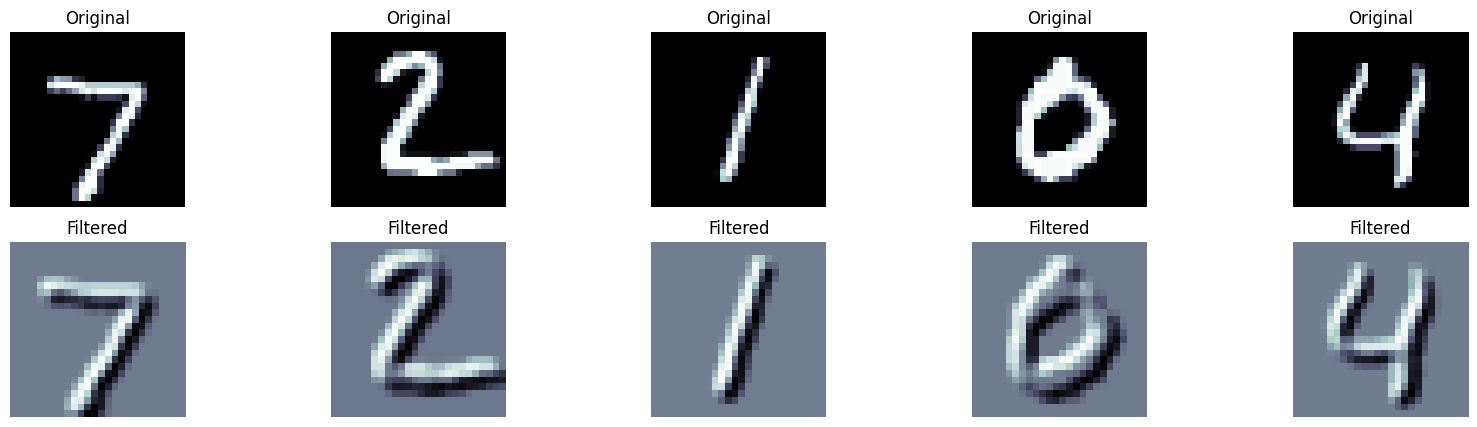

In [7]:
# detecting diagonal edges that point towards the top right
diagonal_filter = [[-2, -1, 0],
                   [-1, 0, 1],
                   [0, 1, 2]]
plot_filter(images, diagonal_filter)

In [8]:
# trying out different subsampling
def plot_subsample(images, pool_type, pool_size):

    images = torch.cat([i.unsqueeze(0) for i in images], dim=0).cpu()

    if pool_type.lower() == 'max':
        pool = F.max_pool2d
    elif pool_type.lower() in ['mean', 'avg']:
        pool = F.avg_pool2d
    else:
        raise ValueError(f'pool_type must be either max or mean, got: {pool_type}')

    n_images = images.shape[0]

    pooled_images = pool(images, kernel_size=pool_size)

    fig = plt.figure(figsize=(20, 5))

    for i in range(n_images):

        ax = fig.add_subplot(2, n_images, i+1)
        ax.imshow(images[i].squeeze(0), cmap='bone')
        ax.set_title('Original')
        ax.axis('off')

        image = pooled_images[i].squeeze(0)

        ax = fig.add_subplot(2, n_images, n_images+i+1)
        ax.imshow(image, cmap='bone')
        ax.set_title('Subsampled')
        ax.axis('off')


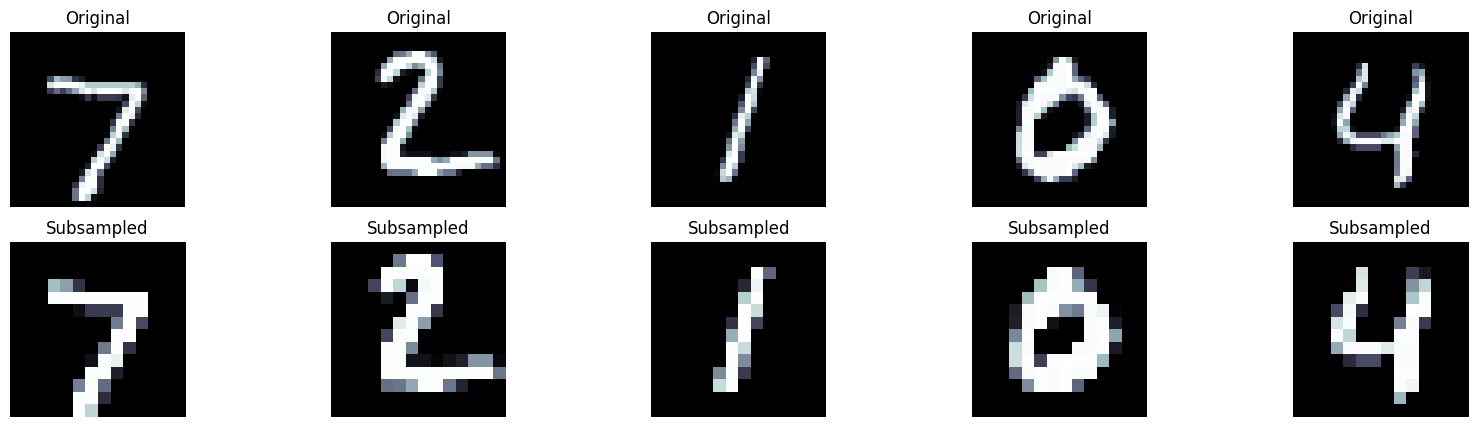

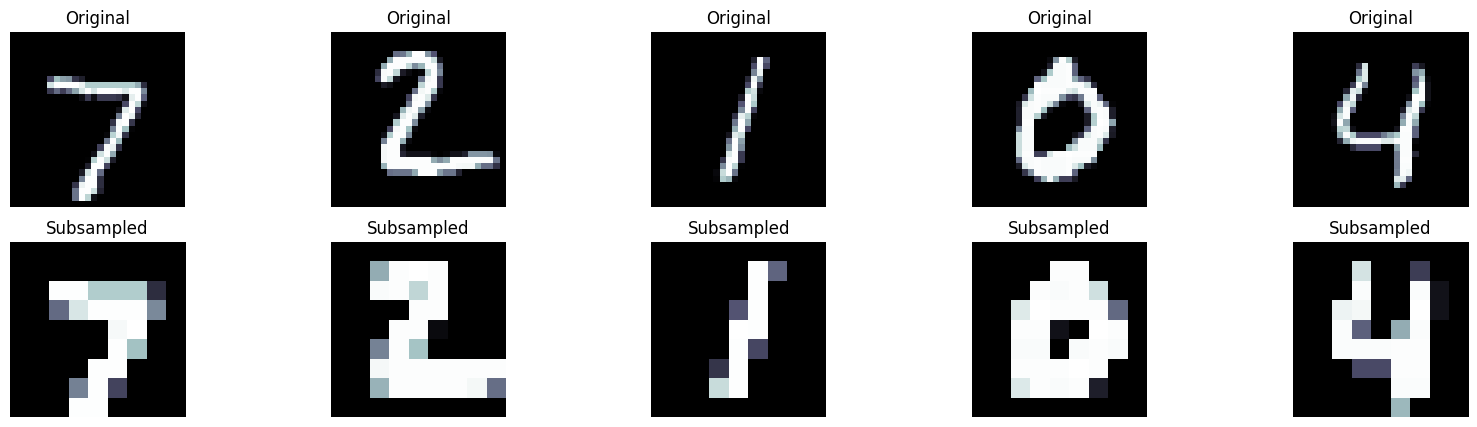

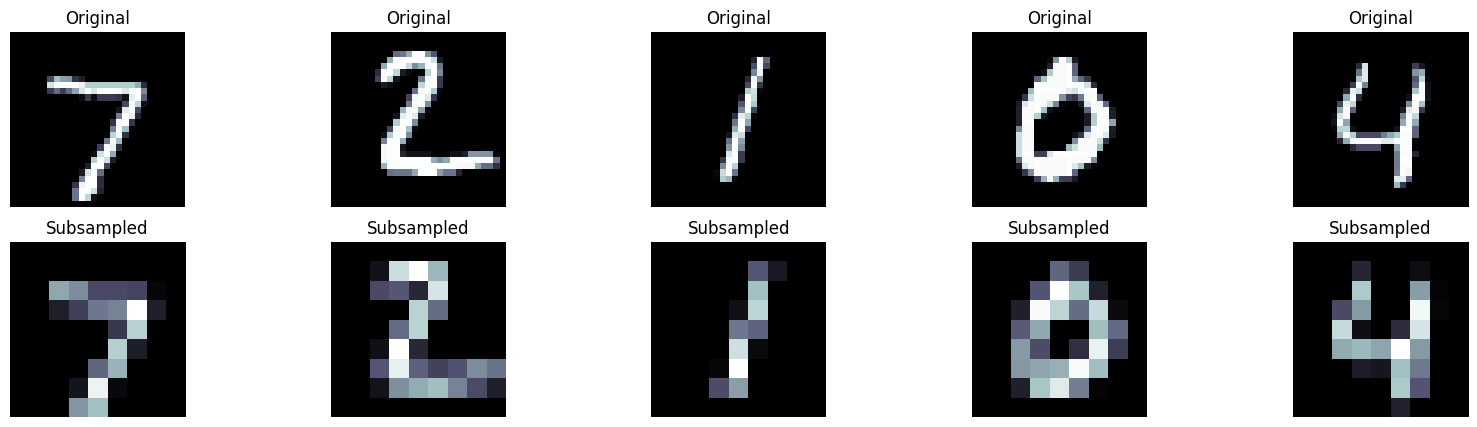

In [9]:
plot_subsample(images, 'max', 2)
plot_subsample(images, 'max', 3)
plot_subsample(images, 'avg', 3)

In [10]:
'''
The image size is 28x28.
Our first layer has 6 filters with kernel size 5x5.
This transforms our [1, 28, 28] image to [6, 24, 24].
A max pooling layer of size 2 reduces the image to [6, 12, 12].
Then the image is passed through the ReLU activation function.

Our second layer has 16 filters with kernel size 5x5x6, transforming our image to [16, 8, 8].
A second max pooling layer further reduces the image to [16, 4, 4].
The image is passed through ReLU once more.

Finally, we flatten the [16, 4, 4] to [256].
We pass it through 3 linear layers, the first two being followed by ReLU.
'''

'\nThe image size is 28x28.\nOur first layer has 6 filters with kernel size 5x5.\nThis transforms our [1, 28, 28] image to [6, 24, 24].\nA max pooling layer of size 2 reduces the image to [6, 12, 12].\nThen the image is passed through the ReLU activation function.\n\nOur second layer has 16 filters with kernel size 5x5x6, transforming our image to [16, 8, 8].\nA second max pooling layer further reduces the image to [16, 4, 4].\nThe image is passed through ReLU once more.\n\nFinally, we flatten the [16, 4, 4] to [256].\nWe pass it through 3 linear layers, the first two being followed by ReLU.\n'

In [11]:
class LeNet(nn.Module):
  def __init__(self, output_dim):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)
    self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
    self.fc_1 = nn.Linear(16 * 4 * 4, 120)
    self.fc_2 = nn.Linear(120, 84)
    self.fc_3 = nn.Linear(84, output_dim)

  def forward(self, x):
    x = self.conv1(x)
    x = F.max_pool2d(x, kernel_size=2)
    x = F.relu(x)

    x = self.conv2(x)
    x = F.max_pool2d(x, kernel_size=2)
    x = F.relu(x)

    x = x.view(x.shape[0], -1)
    h = x
    x = self.fc_1(x)
    x = F.relu(x)
    x = self.fc_2(x)
    x = F.relu(x)
    x = self.fc_3(x)
    return x, h

In [12]:
OUTPUT_DIM = 10
model = LeNet(OUTPUT_DIM)

def count_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'The model has {count_parameters(model): } trainable parameters')

The model has  44426 trainable parameters


In [22]:
# training the model
optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = criterion.to(device)

def calculate_accuracy(y_pred, y):
  top_pred = y_pred.argmax(1, keepdim=True)
  correct = top_pred.eq(y.view_as(top_pred)).sum()
  acc = correct.float() / y.shape[0]
  return acc

def train(model, iterator, optimizer, criterion, device):
    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for (x, y) in tqdm(iterator, desc="Training", leave=False):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        y_pred, _ = model(x)
        loss = criterion(y_pred, y)
        acc = calculate_accuracy(y_pred, y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)


def evaluate(model, iterator, criterion, device):
    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad():
        for (x, y) in tqdm(iterator, desc="Evaluating", leave=False):
            x = x.to(device)
            y = y.to(device)

            y_pred, _ = model(x)
            loss = criterion(y_pred, y)
            acc = calculate_accuracy(y_pred, y)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs


In [23]:
EPOCHS = 20
best_valid_loss = float('inf')

for epoch in trange(EPOCHS, desc="Epochs"):
  start_time = time.monotonic()

  train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
  valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)

  if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tut2-model.pt')

  end_time = time.monotonic()

  epoch_mins, epoch_secs = epoch_time(start_time, end_time)

  print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
  print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
  print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')


Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/844 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch: 01 | Epoch Time: 0m 26s
	Train Loss: 0.413 | Train Acc: 86.93%
	 Val. Loss: 0.140 |  Val. Acc: 95.95%


Training:   0%|          | 0/844 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch: 19 | Epoch Time: 0m 26s
	Train Loss: 0.031 | Train Acc: 98.99%
	 Val. Loss: 0.046 |  Val. Acc: 98.74%


Training:   0%|          | 0/844 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch: 20 | Epoch Time: 0m 26s
	Train Loss: 0.031 | Train Acc: 99.04%
	 Val. Loss: 0.041 |  Val. Acc: 98.88%


In [24]:
model.load_state_dict(torch.load('tut2-model.pt'))
test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

Test Loss: 0.023 | Test Acc: 99.29%


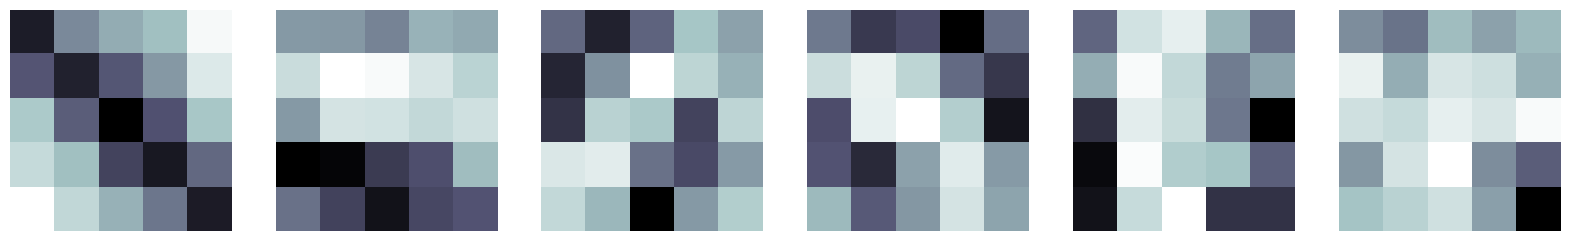

In [26]:
# taking a look at the filters
filters = model.conv1.weight.data

def plot_filters(filters):
  filters = filters.cpu()
  n_filters = filters.shape[0]
  fig = plt.figure(figsize=(20, 10))

  for i in range(n_filters):
    ax = fig.add_subplot(1, n_filters, i+1)
    ax.imshow(filters[i].squeeze(0), cmap='bone')
    ax.axis('off')

plot_filters(filters)